## Exploratory Data Analysis

### This notebook performs Exploratory Data Analysis (EDA) on the sentiment dataset for the challenge. It explores class balance, text length distributions, and text cleanliness.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import emoji

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

In [2]:
def clean_for_eda(text, keep_emojis=True):
    """
    Normalize social media text for EDA.
    - Always normalizes URLs and mentions.
    - Emojis are kept or removed based on `keep_emojis`.
    """
    text = str(text)

    # Normalize URLs (replace with <URL>)
    text = re.sub(r'http\S+|www\S+|bit\.ly\S+|store\.playstation\.com\S*', '<URL>', text)

    # Normalize @mentions (replace with <USER>)
    text = re.sub(r'@\w+', '<USER>', text)

    # Handle emojis
    if keep_emojis:
        # Keep emojis as they are (for BERT)
        pass
    else:
        # Remove emojis for non-BERT EDA
        text = emoji.replace_emoji(text, replace='')

    # Normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [3]:
eda_df = pd.read_csv('E://CV//Internship//Coding_Challenge_Omkar_Pawar//data//cleaned_sentiment_dataset.csv')

In [4]:
df_1 = eda_df.copy()

In [5]:
df_1

,id,product,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
70422,7516,LeagueOfLegends,Neutral,♥️ Suikoden 2\r\n1️⃣ Alex Kidd in Miracle Worl...
70423,5708,HomeDepot,Positive,Thank you to Matching funds Home Depot RW paym...
70424,2165,CallOfDuty,Neutral,Late night stream with the boys! Come watch so...
70425,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...


### Class balance

,count,pct%
sentiment,,
Negative,21253,30.18
Positive,19272,27.36
Neutral,17258,24.50
Irrelevant,12644,17.95


Text(0, 0.5, 'count')

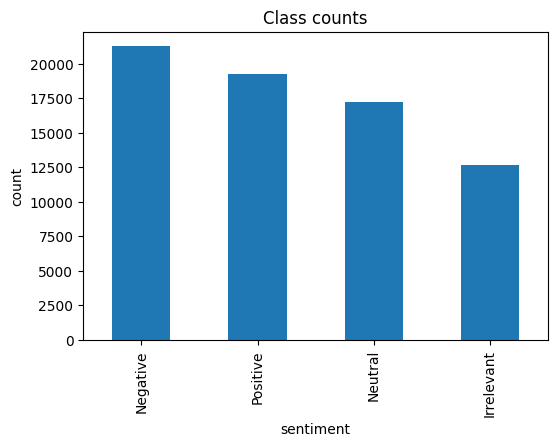

In [6]:
pct = (df_1['sentiment'].value_counts(normalize=True)*100).round(2)
cnt = df_1['sentiment'].value_counts()
display(pd.DataFrame({'count':cnt, 'pct%':pct}))
plt.figure(figsize=(6,4))
df_1['sentiment'].value_counts().plot(kind='bar'); plt.title('Class counts'); plt.ylabel('count')

- Sentiment distribution: Negative > Positive > Neutral > Irrelevant. 
- Classes are moderately balanced with no category underrepresented (<10%).
- Higher Negative count likely reflects natural user bias toward complaints. 
- Positive and Neutral are close, suggesting a realistic mix of sentiment.
- while Irrelevant is smallest.

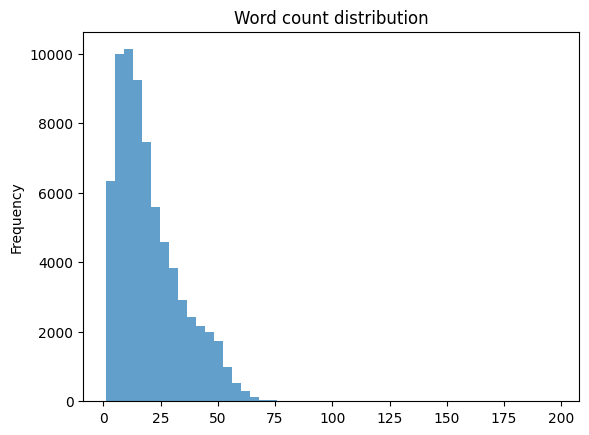

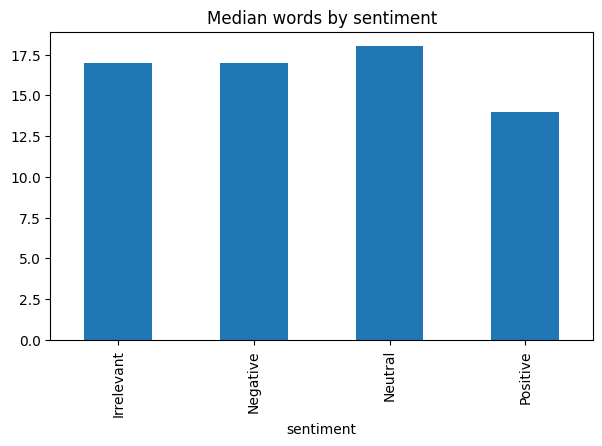

In [7]:
#Text length distribution (overall & by class)

df_1['n_chars'] = df_1['text'].str.len()
df_1['n_words'] = df_1['text'].str.split().str.len()

df_1[['n_words','n_chars']].describe()

ax = df_1['n_words'].plot(kind='hist', bins=50, alpha=0.7, title='Word count distribution')
plt.figure(figsize=(7,4))
df_1.groupby('sentiment')['n_words'].median().plot(kind='bar'); plt.title('Median words by sentiment');

- Word Count Distribution:
- Most texts are short (≈10–25 words), with very few exceeding 75 words.
- The dataset resembles short, social-media-style inputs; long-form reviews are rare.
- A max sequence length of ~50 words (≈95th percentile) is sufficient for transformer models.
- Positive texts are typically shorter (brief praise), while Neutral and Negative texts are longer and more descriptive.
- This may cause text length to act as an indirect sentiment signal.

In [8]:
np.percentile(df_1['n_words'], [90, 95, 99])

array([42., 49., 59.])

### Token/character cleanliness check

In [9]:
# share of texts with urls, @mentions, hashtags, emojis-like chars
has_url = df_1['text'].str.contains(r'http[s]?://|bit\.ly|store\.playstation', case=False, regex=True)
has_mention = df_1['text'].str.contains(r'@\w+')
has_emojiish = df_1['text'].str.contains(r'[\U0001F300-\U0001FAFF]')

pd.DataFrame({
 'has_url%': [has_url.mean()*100],
 'has_mention%':[has_mention.mean()*100],
 'has_emoji%':[has_emojiish.mean()*100]
}).round(2)


,has_url%,has_mention%,has_emoji%
0,3.05,16.49,1.35


In [10]:
eda_bert_df = df_1.copy()
eda_non_bert_df = df_1.copy()

In [11]:
# BERT version (keep emojis)
eda_bert_df['text'] = eda_bert_df['text'].apply(lambda x: clean_for_eda(x, keep_emojis=True))

# Non-BERT version (remove emojis)
eda_non_bert_df['text'] = eda_non_bert_df['text'].apply(lambda x: clean_for_eda(x, keep_emojis=False))

URLs replaced with <URL>

Mentions replaced with <USER>

Emojis kept in BERT and removed in non-BERT.

### Key Terms and Phrases per Sentiment (TF-IDF Analysis)

In [12]:
## old code
sentiment_stop = {'user','url','com','www','http','https'}   # artifacts to drop

def top_ngrams_clean(sub, ngram=(1,2), topk=20):
    vec = TfidfVectorizer(
        ngram_range=ngram,
        min_df=5,
        max_df=0.85,                 # drop very-common terms
        stop_words='english',        # remove stopwords
        token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b',  # words with >=2 letters
        lowercase=True,
        sublinear_tf=True
    )
    X = vec.fit_transform(sub['text'])
    feats = np.array(vec.get_feature_names_out())

    # remove artifact features if present
    keep = ~np.isin(feats, list(sentiment_stop))
    X = X[:, keep]
    feats = feats[keep]

    scores = np.asarray(X.mean(axis=0)).ravel()
    out = pd.DataFrame({'term': feats, 'tfidf': scores})
    return out.sort_values('tfidf', ascending=False).head(topk)
from sklearn.feature_extraction.text import TfidfVectorizer

for s in eda_non_bert_df['sentiment'].unique():
    print(f'=== {s} ===')
    display(top_ngrams_clean(eda_non_bert_df[eda_non_bert_df['sentiment']==s], ngram=(1,2), topk=20))


=== Positive ===


,term,tfidf
7725,love,0.017515
4697,game,0.014318
5246,good,0.014109
6751,just,0.011105
9633,pic,0.010964
912,best,0.010935
13860,wait,0.010407
7297,like,0.010274
10462,really,0.009910
13278,twitter,0.009905


=== Neutral ===


,term,tfidf
7919,just,0.012225
7792,johnson,0.011881
5733,game,0.009769
383,amazon,0.008993
15541,unk,0.008482
15329,tv,0.008385
11158,pic,0.008025
3610,dead,0.007914
12267,red,0.007806
15393,twitter,0.007681


=== Negative ===


,term,tfidf
5770,game,0.018133
13775,shit,0.012656
5539,fuck,0.012613
8014,just,0.011913
16486,user user,0.010353
11329,pic,0.010283
15927,twitter,0.010156
8701,like,0.009686
15929,twitter com,0.009197
5177,fix,0.009137


=== Irrelevant ===


,term,tfidf
7510,player,0.015894
625,ban,0.014151
5203,just,0.010902
5660,like,0.010127
6010,love,0.009901
7278,people,0.009791
766,best,0.009788
10006,time,0.009582
10489,unk,0.009413
4019,good,0.009129


- Identify top unigrams and bigrams per sentiment using TF-IDF.
- Highlights most distinctive words and phrases associated with each sentiment class.

### Chi-Square Feature Importance per Sentiment

In [19]:
vec = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=5,
    max_df=0.85,
    stop_words='english',
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b',
    lowercase=True,
    sublinear_tf=True
)
X = vec.fit_transform(eda_non_bert_df['text'])
y = eda_non_bert_df['sentiment']
feats = np.array(vec.get_feature_names_out())

for cls in y.unique():
    chi2_scores, p_values = chi2(X, (y == cls))
    top_idx = chi2_scores.argsort()[::-1][:20]
    print(f'=== Most discriminative for {cls} ===')
    display(pd.DataFrame({
        'term': feats[top_idx],
        'chi2': chi2_scores[top_idx],
        'p_value': p_values[top_idx]
    }))


=== Most discriminative for Positive ===


,term,chi2,p_value
0,love,307.782522,6.641908e-69
1,wait,253.003720,5.749326e-57
2,fun,182.723114,1.232759e-41
3,excited,169.488074,9.571438e-39
4,creed,165.379654,7.557462e-38
5,nice,153.369801,3.180197e-35
6,wow,145.646430,1.551091e-33
7,thank,144.080877,3.411209e-33
8,good,134.912909,3.449735e-31
9,amazing,125.621241,3.721447e-29


=== Most discriminative for Neutral ===


,term,chi2,p_value
0,johnson,241.488881,1.862375e-54
1,url,217.425366,3.296034e-49
2,earned,189.915013,3.318042e-43
3,just earned,188.483369,6.813740e-43
4,amazon,166.669339,3.950548e-38
5,achievement,162.415139,3.357325e-37
6,chance win,123.942351,8.672705e-29
7,check,112.466533,2.823917e-26
8,com,111.095468,5.638878e-26
9,johnson johnson,108.240375,2.380800e-25


=== Most discriminative for Negative ===


,term,chi2,p_value
0,fix,426.043908,1.180158e-94
1,fuck,247.143773,1.089274e-55
2,servers,221.025995,5.402443e-50
3,shit,179.835134,5.265229e-41
4,eamaddennfl,157.592538,3.799041e-36
5,user,149.055715,2.788445e-34
6,wtf,148.677466,3.373204e-34
7,love,144.942303,2.210930e-33
8,user fix,141.922597,1.011128e-32
9,sucks,111.161355,5.454550e-26


=== Most discriminative for Irrelevant ===


,term,chi2,p_value
0,player,564.465134,8.980677e-125
1,com player,544.342850,2.141221e-120
2,player ban,542.930442,4.344343e-120
3,ban,508.168737,1.587254e-112
4,details com,442.464922,3.147658e-98
5,occurred,417.299031,9.448191e-93
6,occurred details,378.818430,2.250136e-84
7,battlefield player,378.411027,2.759990e-84
8,details,377.405140,4.569914e-84
9,ban battlefield,327.236263,3.843620e-73


 - Identify the most discriminative unigrams and bigrams for each sentiment using Chi-square scores on TF-IDF features. 
 - Highlights words and phrases most strongly associated with each sentiment class.

### Sentiment Distribution by Product

In [24]:
pivot = pd.crosstab(eda_non_bert_df['product'], eda_non_bert_df['sentiment'], normalize='index').round(3)
display(pivot.sort_values('Negative', ascending=False).head(15))

sentiment,Irrelevant,Negative,Neutral,Positive
product,,,,
MaddenNFL,0.044,0.715,0.079,0.162
NBA2K,0.077,0.635,0.113,0.175
FIFA,0.246,0.501,0.045,0.208
TomClancysRainbowSix,0.049,0.477,0.263,0.211
Verizon,0.078,0.460,0.238,0.224
HomeDepot,0.134,0.395,0.151,0.320
TomClancysGhostRecon,0.016,0.385,0.336,0.263
CallOfDuty,0.291,0.370,0.157,0.182
johnson&johnson,0.085,0.360,0.445,0.111


In [25]:
display(pivot.sort_values('Positive', ascending=False).head(15))

sentiment,Irrelevant,Negative,Neutral,Positive
product,,,,
AssassinsCreed,0.122,0.168,0.071,0.640
Borderlands,0.108,0.189,0.266,0.437
Cyberpunk2077,0.215,0.164,0.210,0.411
PlayStation5(PS5),0.178,0.189,0.221,0.411
RedDeadRedemption(RDR),0.098,0.135,0.356,0.411
CallOfDutyBlackopsColdWar,0.245,0.237,0.152,0.367
Hearthstone,0.100,0.232,0.303,0.365
Nvidia,0.046,0.228,0.386,0.341
Xbox(Xseries),0.317,0.161,0.183,0.338


- Compute normalized sentiment proportions per product to identify 
- which products receive more positive or negative feedback on average.
- Helps reveal product-level sentiment trends or bias in the dataset.
- AssassinsCreed and Borderlands show the highest share of positive sentiment, suggesting strong user satisfaction.
Over 70% of MaddenNFL posts were negative, indicating widespread dissatisfaction, while HomeDepot and Overwatch had more balanced sentiment distributions.
    
- The 'product' column is excluded from modeling to prevent data leakage.
- Although products may show sentiment trends, the goal is to learn sentiment from text itself.
- Product info is used only for EDA and not as a predictive feature.

### Vocabulary Analysis and Out-of-Vocabulary (OOV) Risk

In [29]:
tokens = eda_non_bert_df['text'].str.lower().str.replace(r'[^a-z0-9\s]', ' ', regex=True).str.split()
vocab = Counter([t for row in tokens for t in row])
len_vocab = len(vocab); pct_singletons = (sum(1 for k,v in vocab.items() if v==1)/len_vocab)*100
len_vocab, round(pct_singletons,2)

(30828, 23.88)

I analyzed the dataset’s vocabulary coverage to assess out-of-vocabulary risk for classical NLP models.
The corpus contained about 30K unique tokens, with roughly 24% being singletons — words that appear only once.
This indicates a moderately rich vocabulary but also some noise or rare terms, which could increase OOV risk during inference.
Based on this, I would use TF-IDF with min_df=2–3 to filter rare terms.

In [30]:
tokens = eda_non_bert_df['text'].str.lower().str.replace(r'[^a-z0-9\s]', ' ', regex=True).str.split()
vocab = Counter([t for row in tokens for t in row])
# all unique words (≈30K)
all_words = list(vocab.keys())

# words that appear only once
singleton_words = [word for word, count in vocab.items() if count == 1]

print(f"Total unique words: {len(all_words)}")
print(f"Singleton words: {len(singleton_words)} ({len(singleton_words)/len(all_words)*100:.2f}%)")

Total unique words: 30828
Singleton words: 7363 (23.88%)


In [31]:
singleton_words

['megamagwitch',
 'kfdmitch',
 'megamagwife',
 'fendmitch',
 'disssapointing',
 'sobriety',
 'profzeroo',
 'profzero',
 'grosskreutz',
 'testimonies',
 'valensela',
 'pozas',
 'moreno',
 'klein',
 'ethical',
 'provocative',
 'ghostlifestyle',
 'ghostlive',
 'baghad',
 'crossroads',
 'montana',
 'vibrating',
 'trench',
 'foiled',
 'misleadingly',
 'laikenjordahl',
 '2usbp',
 'polyphony',
 'polyslice',
 'slutsky',
 'imitate',
 'demintele',
 'discospider93',
 'bwungus',
 'lstesports',
 'crises',
 'yooooooooooo',
 'yooooooooo',
 '2n68qojkhu',
 'ostik',
 'fusterkluck',
 'klaus',
 'alma',
 'adoptive',
 'poems',
 'omnipotence',
 '2xj2r',
 'conditional',
 'borwkmszrs',
 'subbids',
 '4egaming',
 'commuter',
 'jratt',
 'quietachvment',
 'quicktachement',
 'ointments',
 'canonical',
 'mayan',
 'chiming',
 'swagdeals',
 'joltzdude139',
 'jolddude139',
 'impart',
 'gamegrumps',
 'egoraptor',
 'gamegrup',
 'sidewalks',
 'kensington',
 'xxxaiii',
 'googfcits',
 'ascended',
 'rests',
 'heavyweights',


 Analyze vocabulary coverage to estimate OOV risk for classical NLP models.
- The dataset contains ~30K unique tokens, with ~24% appearing only once (singletons).
- Indicates a moderately rich vocabulary with some rare/noisy terms.
- Suggests applying lemmatization and TF-IDF filtering (min_df=2–3) 

### Punctuation Analysis

In [34]:
eda_non_bert_df.groupby('sentiment')['n_words'].describe()[['50%','75%','max']]
eda_non_bert_df['exclaim'] = eda_non_bert_df['text'].str.count('!')
eda_non_bert_df.groupby('sentiment')['exclaim'].mean().round(2)

sentiment
Irrelevant    0.41
Negative      0.26
Neutral       0.43
Positive      0.56
Name: exclaim, dtype: float64

- Analyze text length and punctuation usage across sentiment classes.
- Positive texts show higher average exclamation counts (0.56) than negative (0.26),
- indicating greater expressiveness and emotional tone in positive messages.
- This pattern supports label quality and suggests punctuation could be retained as a potential feature